### Polynomial (quadratic) regression using PyTorch

##### **Objective**: To implement polynomial regression using PyTorch's nn.Module API. The model learns the parameters for the function from a CSV dataset and evaluates the model performance using regression metrics(MAE loss).

### 1. Import libraries

In [1]:
import torch
import matplotlib.pyplot as plt
from torch import nn
import pandas as pd 

### 2. Load the dataset

In [ ]:
df = pd.read_csv(r'assignment-data2.csv')
df.head(6)

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00
5,-8.8,543.08


### 3. Data Preparation as PyTorch tensors


In [4]:

X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([99, 1])
torch.Size([99, 1])


### 4. Split the data


In [ ]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(79, 79, 20, 20)

### 5. Visualize training and testing data

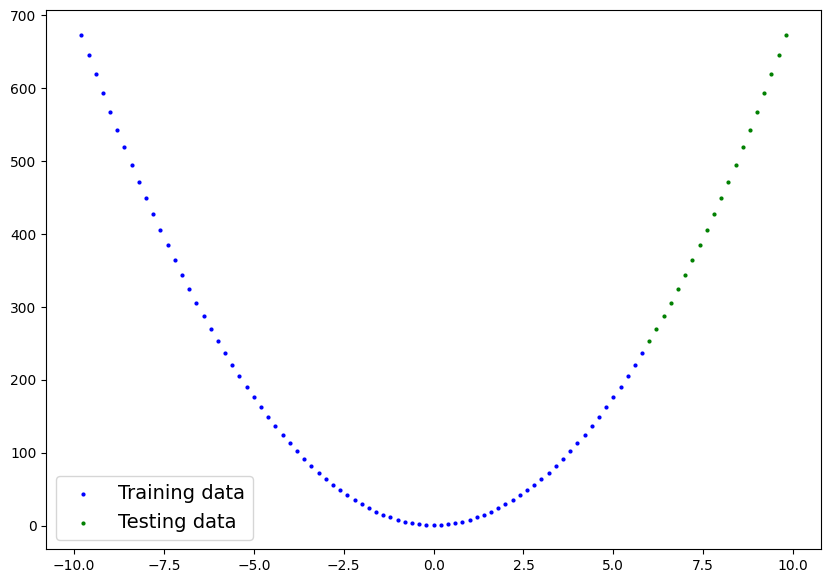

In [7]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

plot_predictions(X_train, y_train, X_test, y_test)

### 6. Create a Linear Regression model class

In [ ]:
# define the Polynomial Regression Model
class LinearRegressionModel(nn.Module): 
    def __init__(self):
        super().__init__() 
        self.weights = nn.Parameter(torch.randn(1, 
                                    dtype=torch.float), 
                                    requires_grad=True) 

        self.bias = nn.Parameter(torch.randn(1, 
                                dtype=torch.float),
                                requires_grad=True) 

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x**2 + self.bias 

### 7. Initialize Model and Inspect Parameters

In [9]:
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [10]:
print(model_0.weights.dtype)
print(model_0.bias.dtype)

torch.float32
torch.float32


### 8. Initial Prediction

In [11]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

y_preds[:5]

tensor([[12.2497],
        [13.0712],
        [13.9196],
        [14.7950],
        [15.6974]])

In [12]:
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 20
Number of predictions made: 20
Predicted values:
tensor([[12.2497],
        [13.0712],
        [13.9196],
        [14.7950],
        [15.6974],
        [16.6266],
        [17.5828],
        [18.5660],
        [19.5760],
        [20.6131],
        [21.6770],
        [22.7679],
        [23.8857],
        [25.0304],
        [26.2021],
        [27.4007],
        [28.6263],
        [29.8788],
        [31.1582],
        [32.4646]])


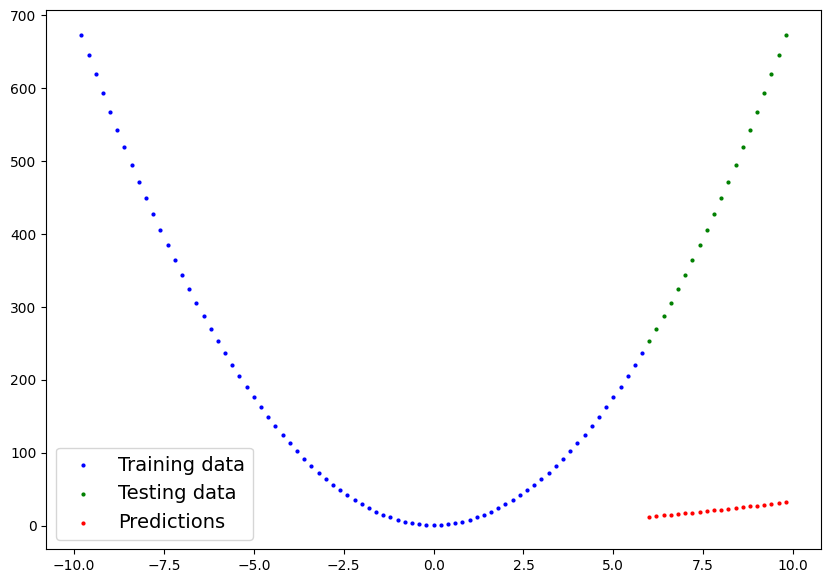

In [13]:
plot_predictions(predictions=y_preds)

### 9. Configure Loss Function and Optimizer

In [14]:
loss_fn = nn.L1Loss() 

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), lr=0.01)

In [2]:
print("Loss function: L1Loss (MAE)")
print("Optimizer: SGD with learning rate = 0.01")

Loss function: L1Loss (MAE)
Optimizer: SGD with learning rate = 0.01


### 10. Training and testing loop

In [15]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 166.12127685546875 | MAE Test Loss: 409.7730407714844 
Epoch: 10 | MAE Train Loss: 104.51728057861328 | MAE Test Loss: 251.5978546142578 
Epoch: 20 | MAE Train Loss: 42.913272857666016 | MAE Test Loss: 93.42262268066406 
Epoch: 30 | MAE Train Loss: 3.944099187850952 | MAE Test Loss: 6.613184928894043 
Epoch: 40 | MAE Train Loss: 2.9400620460510254 | MAE Test Loss: 9.151992797851562 
Epoch: 50 | MAE Train Loss: 2.282644033432007 | MAE Test Loss: 10.805486679077148 
Epoch: 60 | MAE Train Loss: 1.7487810850143433 | MAE Test Loss: 12.143815994262695 
Epoch: 70 | MAE Train Loss: 1.3455159664154053 | MAE Test Loss: 13.149670600891113 
Epoch: 80 | MAE Train Loss: 0.9748930335044861 | MAE Test Loss: 14.072405815124512 
Epoch: 90 | MAE Train Loss: 0.6545260548591614 | MAE Test Loss: 14.867582321166992 


### 11. Plot the loss curves

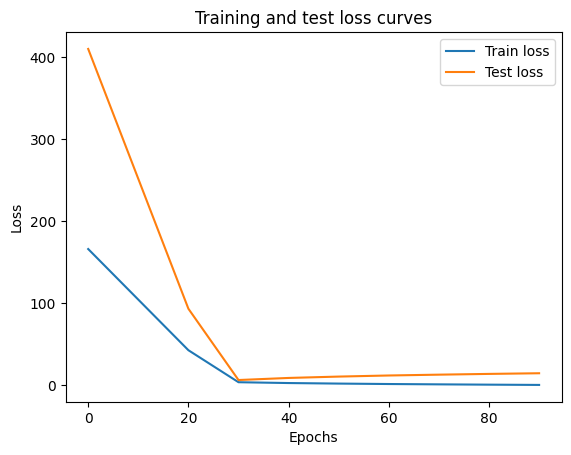

In [ ]:
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

### 12. Inspect the learned parameters

In [ ]:
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([7.0016]), 'bias': tensor([0.5501])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


### 13. Final Prediction

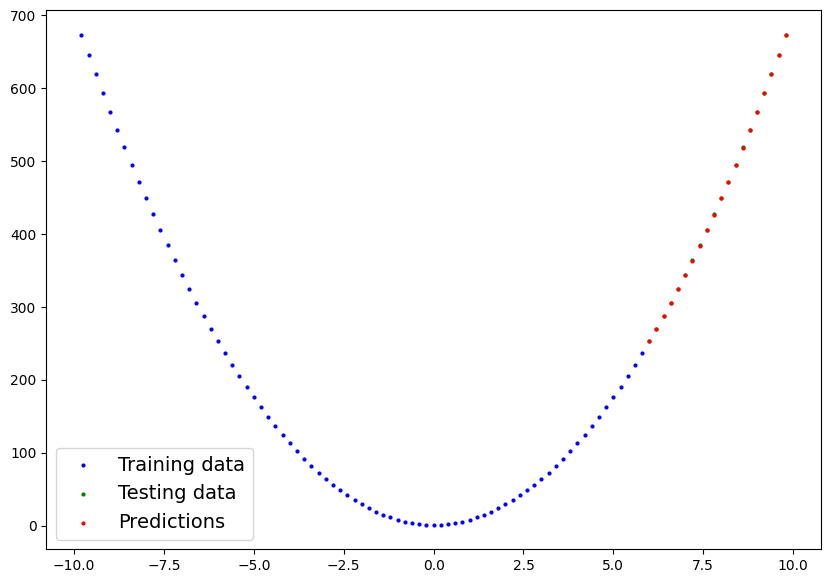

In [18]:
model_0.eval()

with torch.inference_mode():
 
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

### Discussion
We learned about how the PyTorch is used for linear regression. The model was built by defining learnable weight and bias parameters and training them using Stochastic Gradient Descent (SGD). At first, the predictions were inaccurate because the parameters were randomly initialized. However, through iterative training and backpropagation, both training and testing losses decreased significantly. It indicates that the model successfully learned the underlying relationship in the data. The learned parameters closely matched the original values used to generate the dataset, demonstrating the effectiveness of gradient-based optimization. The loss curves also showed stable convergence without signs of overfitting.

### Conclusion

In conclusion, a linear regression model was successfully implemented and trained using PyTorch. The model learned the relationship between input and output data by minimizing the Mean Absolute Error (MAE) loss through SGD optimization. The final learned parameters were very close to the true parameters of the dataset, resulting in accurate predictions on unseen test data. This experiment highlights the fundamental workflow of machine learning in PyTorch, including data preparation, model creation, training, evaluation, and inference.
